# Оценка рыночной стоимости квартир в Москве с помощью полносвязных нейронных сетей

**#Даша:** уточнила бизнес-идею, связь табличной и текстовой задач, ML-постановку, метрики и разбиение.


## 1. Постановка задачи и бизнес-идея

**Бизнес-идея проекта.** Для платформы объявлений о недвижимости можно сделать AI-помощника, который проверяет карточку квартиры до публикации: оценивает адекватность цены, подсвечивает завышение/занижение и отдельно анализирует текст описания. Для продавца это быстрый ориентир по рынку, для платформы — более качественные объявления, меньше недостоверных карточек и выше доверие покупателей.

В общем проекте две задачи связаны одним процессом — созданием и модерацией объявления:

1. **Табличная задача**: оценить рыночную цену квартиры по площади, комнатности, параметрам дома, локации, инфраструктуре и другим структурированным признакам.
2. **Текстовая задача**: анализировать описание объявления и по тексту определять уровень ремонта квартиры. Эту информацию можно использовать во внутреннем алгоритме для рекомендаций пользователям (как продавцам, так и покупателям) партнерских сервисов ремонта, а инвесторам и перекупщикам для выявления объектов, которые можно купить дешевле рынка, улучшить и перепродать дороже. Такой сценарий основан на том, что квартиры с плохим ремонтом обычно стоят ниже аналогичных объектов в хорошем состоянии. Соотвественно на покупке такой квартиры можно заработать

Этот ноутбук закрывает **первую, табличную часть** проекта. Вход модели — очищенная таблица признаков объявления. Выход — прогноз полной цены квартиры в рублях.

**ML-постановка.** Это задача регрессии. Модель обучается на `log1p(цены за м^2)`, потому что цена за квадратный метр лучше отражает рыночный уровень объекта, а не просто его размер. После предсказания цена за м^2 умножается на площадь, поэтому итоговые метрики считаются уже по полной цене квартиры.

**Разбиение.** Используем случайный train/validation/test split. Это соответствует продуктовой задаче интерполяционной оценки: сервис работает внутри уже известного московского рынка, где в обучении есть похожие квартиры из тех же районов и сегментов.

**Метрики.** Основные метрики — `MAPE` и `MdAPE`, потому что бизнесу удобнее читать ошибку в процентах. `RMSLE` оставляем как техническую метрику для контроля лог-пространства и правого хвоста цен.



## 2. Окружение

Для повторного запуска достаточно положить рядом с ноутбуком файл `data (6).csv` и установить зависимости из `requirements.txt`. Эксперименты пишутся в локальный MLflow backend `./mlruns`: там сохраняются параметры запусков, метрики, веса моделей и препроцессоры.

Обучение рассчитано на GPU, но код запускается и на CPU. На CPU полный перебор нейросетей просто займёт больше времени.


In [23]:
%pip install -q mlflow cloudpickle

In [24]:
# Зависимости устанавливаются из requirements.txt перед запуском ноутбука.

import os, re, json, math, copy, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Фиксируем локальное хранилище MLflow, чтобы запуск не зависел от переменных окружения.
os.environ.setdefault('MLFLOW_ALLOW_FILE_STORE', 'true')

import mlflow
import cloudpickle

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 110

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment('moscow-flats-price-dl')

device: cuda


<Experiment: artifact_location='file:///content/mlruns/421668321042831231', creation_time=1781590304466, effective_trace_archival_retention=None, experiment_id='421668321042831231', last_update_time=1781590304466, lifecycle_stage='active', name='moscow-flats-price-dl', tags={}, trace_location=None, workspace='default'>

## 3. Загрузка и очистка данных

Файл «грязный», и это важно обработать явно, а не молча:

1. разделитель — `;`, внутри поля «Описание» есть кавычки и переносы строк;
2. **внутри файла повторяются строки-заголовки** (датасет склеен из нескольких выгрузок) — их нужно выбросить;
3. числа записаны в русской локали: `59,6 м^2`, `2,7`, `100 %`;
4. этаж бывает в формате `44/60` (этаж / этажность дома);
5. в `lat`/`lon`, «Расстояние до центра» и «Качество воздуха» **нулём закодирован пропуск**
   (ровно одна и та же группа из ~3 тыс. строк);
6. датасет — объединение двух сегментов: **новостройки** (заполнены «Отделка», «Аккредитация»,
   «Строительная готовность»…) и **вторичка** (заполнены «Ремонт», «Тип сделки», «Лет в собственности»…);
   из этого делаем признак `is_newbuild` и аккуратно сводим колонки-дубли
   («Материал стен»/«Материалстен», «Количество этажей»/«Количествоэтажей», два «Вида из окон» и т.д.).

In [25]:
CURRENT_YEAR = 2026
DATA_PATH = 'data (6).csv'

def num_ru(s: pd.Series) -> pd.Series:
  # 59,6 м² в число
  s = s.astype(str)
  s = (s.str.replace('\u00a0', '', regex=False)
          .str.replace('м²', '', regex=False)
          .str.replace('м2', '', regex=False)
          .str.replace('%', '', regex=False)
          .str.replace(' ', '', regex=False)
          .str.replace(',', '.', regex=False))
  return pd.to_numeric(s, errors='coerce')

def load_raw(path: str) -> pd.DataFrame:
  df = pd.read_csv(
      path,
      sep=';',
      quotechar='"',
      engine='python',
      on_bad_lines='skip'
  )
  n0 = len(df)

  # В файле могут повторяться строки-заголовки после склейки выгрузок
  df = df[df['Адрес'].astype(str).str.strip() != 'Адрес'].reset_index(drop=True)

  print(f'строк после чтения: {n0}, после очистки заголовков: {len(df)}')
  return df

raw = load_raw(DATA_PATH)
raw.head(3)

строк после чтения: 10481, после очистки заголовков: 10481


,Адрес,Площадь,Жилая,Кухня,Класс жилья,Отделка,Комнат,Вид из окна,Санузел совмещён,Подъезд,...,museum,cultural_heritage,theatre,government,mfc,lat,lon,АО,Качество воздуха,Расстояние до центра
0,"Москва, 2-й Иртышский проезд, к1/4","59,6 м²","21,8 м²","20,5 м²",Бизнес,Чистовая,2.0,Улица,2.0,5.0,...,20,6,0,8,14,"55,810339","37,749777",NaN,0,0
1,"Москва, пос. Коммунарка, улица Александры Мона...","72,2 м²","34,7 м²","15,7 м²",Комфорт,Чистовая,3.0,Двор,2.0,3.0,...,20,1,1,5,0,"55,573195","37,47766",Новомосковский,11,"25844,1"
2,"Москва, Кварцевая улица, 2 к4","59,4 м2","42,4 м²","19,4 м2",Бизнес,Без отделки,2.0,Улица,1.0,1.0,...,0,9,0,1,0,"55,491615","37,335726",Троицкий,11,38877


In [26]:
def clean(df):
    out = pd.DataFrame(index=df.index)

    # таргет
    out['price'] = pd.to_numeric(df['Цена'], errors='coerce')

    # площади и комнаты
    out['area_total'] = num_ru(df['Площадь'])
    out['area_living'] = num_ru(df['Жилая'])
    out['area_kitchen'] = num_ru(df['Кухня'])
    out['rooms'] = pd.to_numeric(df['Комнат'], errors='coerce')

    out['ceiling_h'] = num_ru(df['Высота потолков'])
    out.loc[(out['ceiling_h'] < 2) | (out['ceiling_h'] > 6), 'ceiling_h'] = np.nan

    # этаж, бывает через слеш типа 44/60
    fl = df['Этаж'].astype(str).str.extract(r'^\s*(\d+)\s*(?:/\s*(\d+))?')
    out['floor'] = pd.to_numeric(fl[0], errors='coerce')
    floors_from_fl = pd.to_numeric(fl[1], errors='coerce')

    floors = pd.to_numeric(df['Количество этажей'], errors='coerce')
    floors = floors.fillna(pd.to_numeric(df['Количествоэтажей'], errors='coerce'))
    floors = floors.fillna(floors_from_fl)
    out['floors_total'] = floors

    out['floor_rel'] = (out['floor'] / out['floors_total']).clip(0, 1)
    out['is_first_floor'] = (out['floor'] == 1).astype(float)
    out['is_last_floor'] = (out['floor'] == out['floors_total']).astype(float)

    # год постройки, если нет - берем год ввода в эксплуатацию
    year = pd.to_numeric(df['Год постройки'], errors='coerce')
    year = year.fillna(pd.to_numeric(df['Год ввода в эксплуатацию'], errors='coerce'))
    year.loc[(year < 1850) | (year > 2035)] = np.nan
    out['build_year'] = year
    out['building_age'] = (CURRENT_YEAR - year).clip(lower=0)

    # координаты, нули это пропуски
    lat = num_ru(df['lat'])
    lon = num_ru(df['lon'])
    lat = lat.mask(lat == 0)
    lon = lon.mask(lon == 0)
    lat.loc[(lat < 54.5) | (lat > 57)] = np.nan
    lon.loc[(lon < 35.5) | (lon > 39.5)] = np.nan
    out['lat'] = lat
    out['lon'] = lon

    dist = num_ru(df['Расстояние до центра'])
    out['dist_center'] = dist.mask(dist == 0)

    air = num_ru(df['Качество воздуха'])
    out['air_quality'] = air.mask(air == 0)

    out['metro_time'] = pd.to_numeric(df['Время до метро'], errors='coerce')

    # poi
    poi_cols = [
        'metro', 'bus_stop', 'hospital', 'clinic', 'school',
        'kindergarten', 'restaurant', 'cafe', 'canteen', 'fast_food',
        'museum', 'cultural_heritage', 'theatre', 'government', 'mfc'
    ]
    for c in poi_cols:
        out['poi_' + c] = pd.to_numeric(df[c], errors='coerce')

    # новостройка или вторичка
    is_new = df['Отделка'].notna() | df['Аккредитация'].notna()
    out['is_newbuild'] = is_new.astype(int)
    out['construction_ready'] = np.where(is_new, num_ru(df['Строительнаяготовность']), 100.0)
    out['flats_on_sale'] = pd.to_numeric(df['Всегоквартирв продаже'], errors='coerce')
    out['flats_total'] = pd.to_numeric(df['Количество квартир'], errors='coerce')
    out['lifts'] = pd.to_numeric(df['Количество лифтов'], errors='coerce')

    # бинарные - лифт, газ, мусоропровод
    for col_name, out_name in [('Лифт', 'has_lift'), ('Грузовой лифт', 'has_freight_lift'),
                                ('Газ', 'has_gas'), ('Мусоропровод', 'has_chute')]:
        s = df[col_name].astype(str).str.strip().str.lower()
        out[out_name] = s.isin(['есть', 'да', '1', '2', '3', '4']).astype(float)
        out.loc[df[col_name].isna(), out_name] = np.nan

    # балконы
    balc = pd.to_numeric(df['Балкон'].replace('нет', 0), errors='coerce')
    balc = balc.fillna(pd.to_numeric(df['Количество балконов'], errors='coerce'))
    balc = balc.fillna(pd.to_numeric(df['Балконы'], errors='coerce'))

    loggia = pd.to_numeric(df['Лоджия'], errors='coerce')
    loggia = loggia.fillna(pd.to_numeric(df['Лоджии'], errors='coerce'))

    out['balcony_n'] = balc
    out['loggia_n'] = loggia
    out['has_balcony_or_loggia'] = ((balc.fillna(0) + loggia.fillna(0)) > 0).astype(float)

    # санузлы
    bath_comb = pd.to_numeric(df['Санузел совмещён'], errors='coerce')
    bath_sep = pd.to_numeric(df['Санузел отдельно'], errors='coerce')
    out['bath_n'] = bath_comb.fillna(0) + bath_sep.fillna(0)
    out.loc[bath_comb.isna() & bath_sep.isna(), 'bath_n'] = np.nan

    # вид из окон, там две колонки с почти одинаковым названием
    views = (df['Вид из окон'].fillna('').astype(str) + ' ' +
             df['Вид из окна'].fillna('').astype(str)).str.lower()
    out['view_yard'] = views.str.contains('двор').astype(float)
    out['view_street'] = views.str.contains('улиц').astype(float)
    out['view_park'] = views.str.contains('парк|лес').astype(float)

    # категориальные
    out['repair'] = df['Ремонт'].astype('string').str.strip().str.lower()
    out['repair'] = out['repair'].replace({'евроремонт': 'евро'})

    out['finishing'] = df['Отделка'].astype('string').str.strip().str.lower()
    out['housing_class'] = df['Класс жилья'].astype('string').str.strip().str.lower()
    out['deal_type'] = df['Тип сделки'].astype('string').str.strip().str.lower()
    out['housing_type'] = df['Тип жилья'].astype('string').str.strip().str.lower()

    wall = df['Материал стен'].astype('string').str.strip()
    wall = wall.fillna(df['Материалстен'].astype('string').str.strip())
    out['wall_material'] = wall

    out['ceiling_type'] = df['Тип перекрытий'].astype('string').str.strip().str.lower()
    out['house_series'] = df['Серия дома'].astype('string').str.strip().str.lower()
    out['metro_station'] = df['Метро'].astype('string').str.strip()
    out['okrug'] = df['АО'].astype('string').str.strip()
    out['ownership_years'] = df['Лет в собственности'].astype('string').str.strip().str.lower()
    out['accreditation'] = df['Аккредитация'].astype('string').str.strip().str.lower()

    # адрес - берем первые 2 части для группировки
    addr = df['Адрес'].astype(str)
    addr = addr.str.replace('\u00a0', ' ', regex=False)
    addr = addr.str.replace(r'\s+', ' ', regex=True).str.strip()
    out['addr_group'] = addr.str.split(',').str[:2].str.join(',').str.lower()

    out['description'] = (df['Описание'].fillna('').astype(str)
                          .str.replace(r'\s+', ' ', regex=True).str.strip())
    out['desc_len'] = out['description'].str.len()

    return out


data = clean(raw)
data.shape

(10481, 64)

### Фильтрация битых строк, выбросов и массовый сегмент

Удаляем строки, на которых задача в принципе некорректна, а не «неудобные» объекты:
- цена отсутствует или меньше 1 млн рубуб (в данных есть цена 0 — явный мусор);
- площадь отсутствует или вне диапазона 10–400 м^2;
- цена за м^2 вне коридора 50 тыс. – 3.5 млн руб (за пределами — опечатки в цене/площади).

Отдельно фиксируем **массовый сегмент**: оставляем объекты не дороже 95-го перцентиля полной цены
после базовой очистки. Это не техническая чистка, а осознанное ограничение бизнес-скоупа:
модель оценивает типовой рынок, а верхние 5% дорогих/уникальных объектов анализируются отдельно.


In [27]:
MASS_SEGMENT_Q = 0.95
MASS_SEGMENT_COL = 'price'   # верхний хвост полной цены: дорогие/уникальные объекты

def filter_rows(d: pd.DataFrame) -> pd.DataFrame:
    n0 = len(d)
    d = d[d['price'].notna() & (d['price'] >= 1e6)]
    d = d[d['area_total'].notna() & d['area_total'].between(10, 400)]
    ppm = d['price'] / d['area_total']
    d = d[ppm.between(5e4, 3.5e6)]
    n_after_basic = len(d)

    q95 = d[MASS_SEGMENT_COL].quantile(MASS_SEGMENT_Q)
    d = d[d[MASS_SEGMENT_COL] <= q95]

    print(f'базовая фильтрация: {n0} -> {n_after_basic} '
          f'(удалено {n0 - n_after_basic} строк, {100*(n0-n_after_basic)/n0:.1f}%)')
    print(f'массовый сегмент: оставляем {MASS_SEGMENT_Q:.0%} объектов по {MASS_SEGMENT_COL} '
          f'(порог <= {q95:,.0f} руб), итог: {len(d)} строк')
    return d.reset_index(drop=True)

data = filter_rows(data)
data['price_per_m2'] = data['price'] / data['area_total']
data[['price','price_per_m2','area_total','rooms','metro_time','dist_center']].describe().round(1)


базовая фильтрация: 10481 -> 10436 (удалено 45 строк, 0.4%)
массовый сегмент: оставляем 95% объектов по price (порог <= 113,606,800 руб), итог: 9914 строк


,price,price_per_m2,area_total,rooms,metro_time,dist_center
count,9914.0,9914.0,9914.0,9686.0,9372.0,7192.0
mean,29031563.9,481629.2,60.6,2.1,11.8,15461.5
std,18112469.0,178266.3,29.4,1.0,6.0,26234.8
min,2299000.0,140816.3,10.0,1.0,1.0,1696.5
25%,17459064.2,358263.8,40.1,1.0,7.0,10742.0
50%,23549220.0,442795.2,55.7,2.0,11.0,13665.4
75%,34599915.2,560653.1,73.8,3.0,16.0,16763.4
max,113568000.0,1764462.4,331.5,10.0,49.0,638564.4


In [28]:
# зафиксировала итоговый вход модели через MODEL_FEATURES и отдельно создала model_input/target_data для EDA
NUM_FEATURES = [
    'area_total','area_living','area_kitchen','rooms','ceiling_h',
    'floor','floors_total','floor_rel','is_first_floor','is_last_floor',
    'build_year','building_age','lat','lon','dist_center','air_quality',
    'metro_time','is_newbuild','construction_ready','flats_on_sale',
    'flats_total','lifts','has_lift','has_freight_lift','has_gas','has_chute',
    'balcony_n','loggia_n','has_balcony_or_loggia','bath_n',
    'view_yard','view_street','view_park','desc_len',
] + [f'poi_{c}' for c in ['metro','bus_stop','hospital','clinic','school','kindergarten',
                          'restaurant','cafe','canteen','fast_food','museum',
                          'cultural_heritage','theatre','government','mfc']]

CAT_LOW  = ['repair','finishing','housing_class','deal_type','housing_type',
            'wall_material','ceiling_type','okrug','ownership_years','accreditation']
CAT_HIGH = ['metro_station','house_series']   # высокая кардинальность -> кандидаты на эмбеддинги
CATS = CAT_LOW + CAT_HIGH
MODEL_FEATURES = NUM_FEATURES + CATS

print(f'{len(NUM_FEATURES)} числовых, {len(CATS)} категориальных признаков')
print(f'итоговый вход модели: {len(MODEL_FEATURES)} признаков')

# В EDA дальше смотрим ровно тот же набор колонок, который потом уйдёт в модели.
model_input = data[MODEL_FEATURES].copy()
target_data = data[['price', 'price_per_m2']].copy()

display(pd.DataFrame({'feature': MODEL_FEATURES,
    'role': ['num'] * len(NUM_FEATURES) + ['cat'] * len(CATS),
    'missing_share': model_input[MODEL_FEATURES].isna().mean().values,
    'n_unique': [model_input[c].nunique(dropna=True) for c in MODEL_FEATURES]}).sort_values(['role', 'missing_share'], ascending=[True, False]).head(20))

data[CATS].nunique().sort_values(ascending=False)


49 числовых, 12 категориальных признаков
итоговый вход модели: 61 признаков


,feature,role,missing_share,n_unique
57,ownership_years,cat,0.563244,3
56,okrug,cat,0.319145,12
60,house_series,cat,0.312790,127
50,finishing,cat,0.252774,4
51,housing_class,cat,0.252774,4
58,accreditation,cat,0.252774,2
55,ceiling_type,cat,0.173593,6
49,repair,cat,0.166129,19
52,deal_type,cat,0.146460,4
53,housing_type,cat,0.137381,2


,0
metro_station,330
house_series,127
repair,19
okrug,12
wall_material,10
ceiling_type,6
finishing,4
housing_class,4
deal_type,4
ownership_years,3


**#Даша:** переписала описание EDA: анализ теперь идёт по тому же формату данных, который дальше подаётся в модели.

## 4. Разведочный анализ (EDA)

EDA сделан в том же формате, в котором данные дальше попадают в модели: `model_input = data[MODEL_FEATURES]`, таргет отдельно — `price` и `price_per_m2`. Поэтому каждый график ниже отвечает на практический вопрос для моделирования: какой таргет брать, какие признаки важны, где есть пропуски, почему нужны нелинейные сети и зачем отдельно проверять embeddings для категорий.


Размер данных для EDA: (9914, 64)
Размер входа модели: (9914, 61)
Доля полностью заполненных строк по признакам модели: 0.004


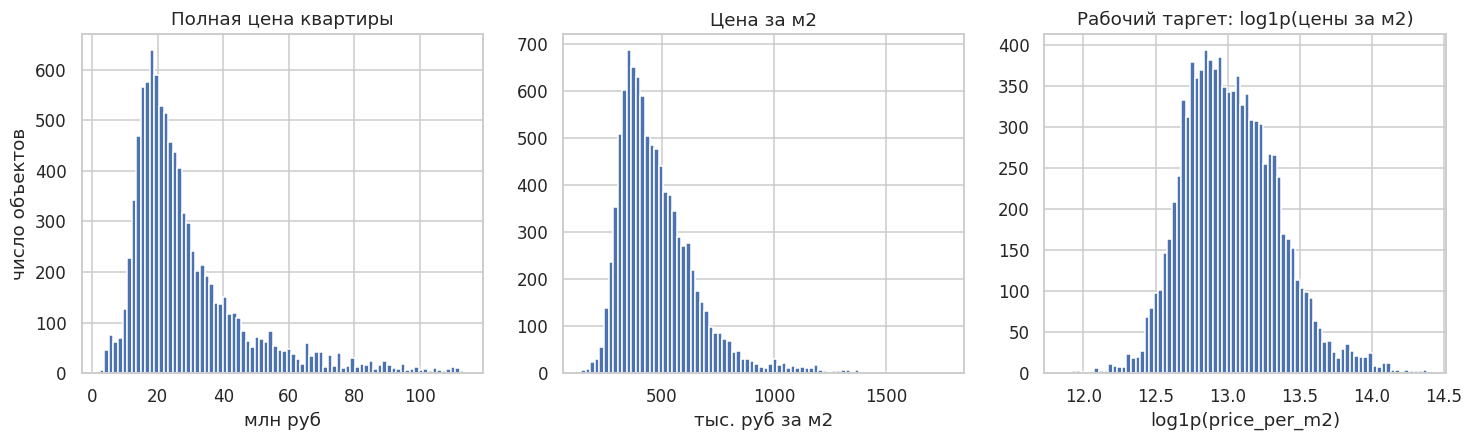

,target,mean,median,skew
0,price_per_m2,481629.159,442795.249,1.857
1,log1p_price_per_m2,13.028,13.001,0.478


In [29]:
#добавила EDA по рабочему таргету: полная цена, цена за м^2, log1p(price_per_m2), размерность входа и проверка скошенности
eda = pd.concat([model_input, target_data], axis=1)
eda['log_price_per_m2'] = np.log1p(eda['price_per_m2'])

print('Размер данных для EDA:', eda.shape)
print('Размер входа модели:', model_input.shape)
print('Доля полностью заполненных строк по признакам модели:', round(model_input.notna().all(axis=1).mean(), 3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(eda['price'] / 1e6, bins=80)
axes[0].set_title('Полная цена квартиры')
axes[0].set_xlabel('млн руб')
axes[0].set_ylabel('число объектов')

axes[1].hist(eda['price_per_m2'] / 1000, bins=80)
axes[1].set_title('Цена за м2')
axes[1].set_xlabel('тыс. руб за м2')

axes[2].hist(eda['log_price_per_m2'], bins=80)
axes[2].set_title('Рабочий таргет: log1p(цены за м2)')
axes[2].set_xlabel('log1p(price_per_m2)')
plt.show()

# Численно фиксируем, что логарифмирование делает распределение спокойнее.
target_check = pd.DataFrame({
    'target': ['price_per_m2', 'log1p_price_per_m2'],
    'mean': [eda['price_per_m2'].mean(), eda['log_price_per_m2'].mean()],
    'median': [eda['price_per_m2'].median(), eda['log_price_per_m2'].median()],
    'skew': [eda['price_per_m2'].skew(), eda['log_price_per_m2'].skew()],
})
display(target_check.round(3))


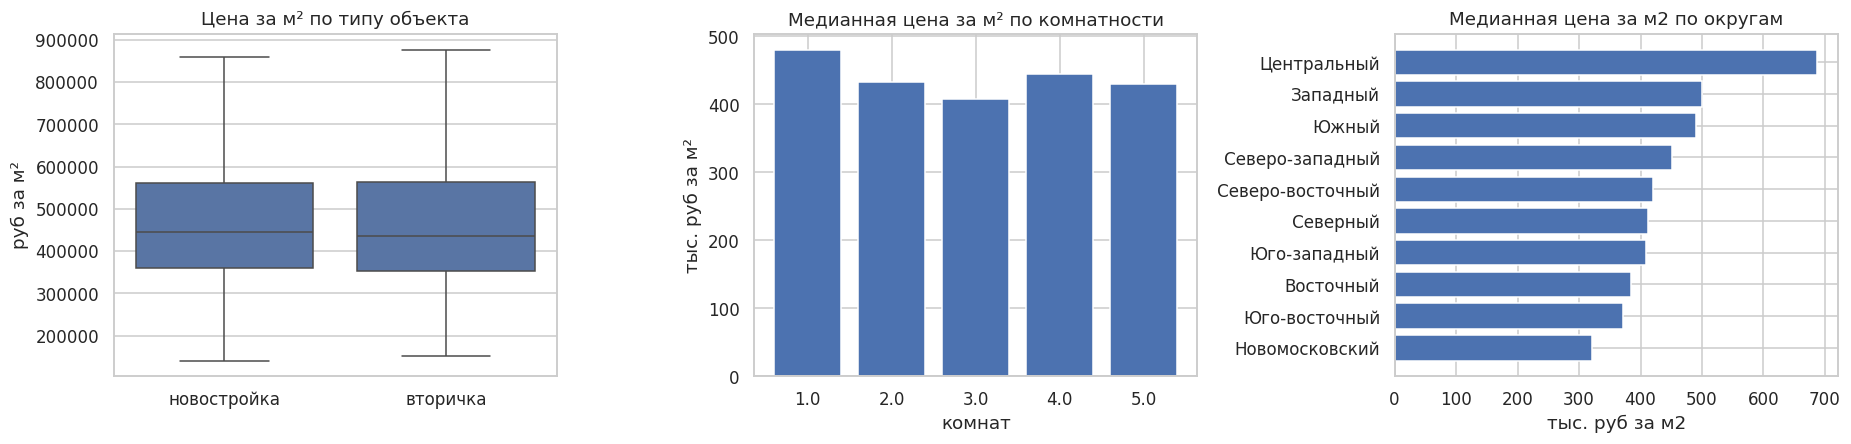

,price,price_per_m2,area_total,dist_center
segment,,,,
вторичка,24265000.0,436026.3,57.2,13356.7
новостройка,23415775.5,444489.7,55.0,13738.8


In [30]:
#добавила бизнес-сегменты EDA: новостройка/вторичка, комнатность и округи
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

seg = data.copy()
seg['segment'] = np.where(seg['is_newbuild'] == 1, 'новостройка', 'вторичка')
sns.boxplot(data=seg, x='segment', y='price_per_m2', showfliers=False, ax=axes[0])
axes[0].set_title('Цена за м² по типу объекта')
axes[0].set_xlabel('')
axes[0].set_ylabel('руб за м²')

room_stat = (seg.groupby('rooms', observed=True)['price_per_m2']
             .agg(['count', 'median'])
             .query('count >= 50')
             .sort_index())
axes[1].bar(room_stat.index.astype(str), room_stat['median'] / 1000)
axes[1].set_title('Медианная цена за м² по комнатности')
axes[1].set_xlabel('комнат')
axes[1].set_ylabel('тыс. руб за м²')

okrug_stat = (seg.groupby('okrug', observed=True)['price_per_m2']
              .agg(['count', 'median'])
              .query('count >= 50')
              .sort_values('median'))
axes[2].barh(okrug_stat.index.astype(str), okrug_stat['median'] / 1000)
axes[2].set_title('Медианная цена за м2 по округам')
axes[2].set_xlabel('тыс. руб за м2')
plt.tight_layout() #ломается без него
plt.show()

display(seg.groupby('segment')[['price', 'price_per_m2', 'area_total', 'dist_center']]
        .median().rename(index={0: 'вторичка', 1: 'новостройка'}).round(1))


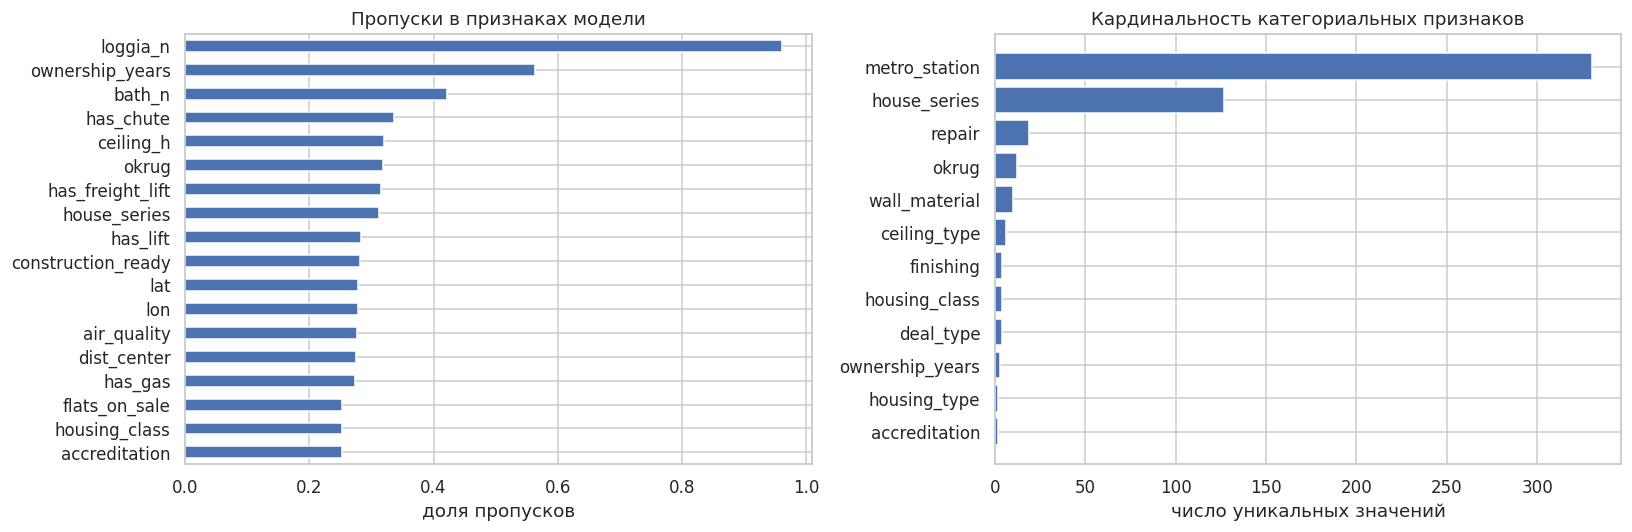

,feature,n_unique,missing_share
10,metro_station,330,0.004539
11,house_series,127,0.312790
0,repair,19,0.166129
7,okrug,12,0.319145
5,wall_material,10,0.014525
6,ceiling_type,6,0.173593
1,finishing,4,0.252774
2,housing_class,4,0.252774
3,deal_type,4,0.146460
8,ownership_years,3,0.563244


In [31]:
#добавила проверку пропусков и кардинальности категориальных признаков именно на model_input
#Пропуски и кардинальность смотрим на model_input, а не на исходной сырой таблице
miss = model_input.isna().mean().sort_values(ascending=False)
miss_top = miss[miss > 0].head(18).sort_values()

card = pd.DataFrame({
    'feature': CATS,
    'n_unique': [model_input[c].nunique(dropna=True) for c in CATS],
    'missing_share': [model_input[c].isna().mean() for c in CATS],
}).sort_values('n_unique', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
miss_top.plot(kind='barh', ax=axes[0])
axes[0].set_title('Пропуски в признаках модели')
axes[0].set_xlabel('доля пропусков')

axes[1].barh(card['feature'], card['n_unique'])
axes[1].set_title('Кардинальность категориальных признаков')
axes[1].set_xlabel('число уникальных значений')
axes[1].invert_yaxis()
plt.tight_layout() #ломается без него
plt.show()

card.head(12)


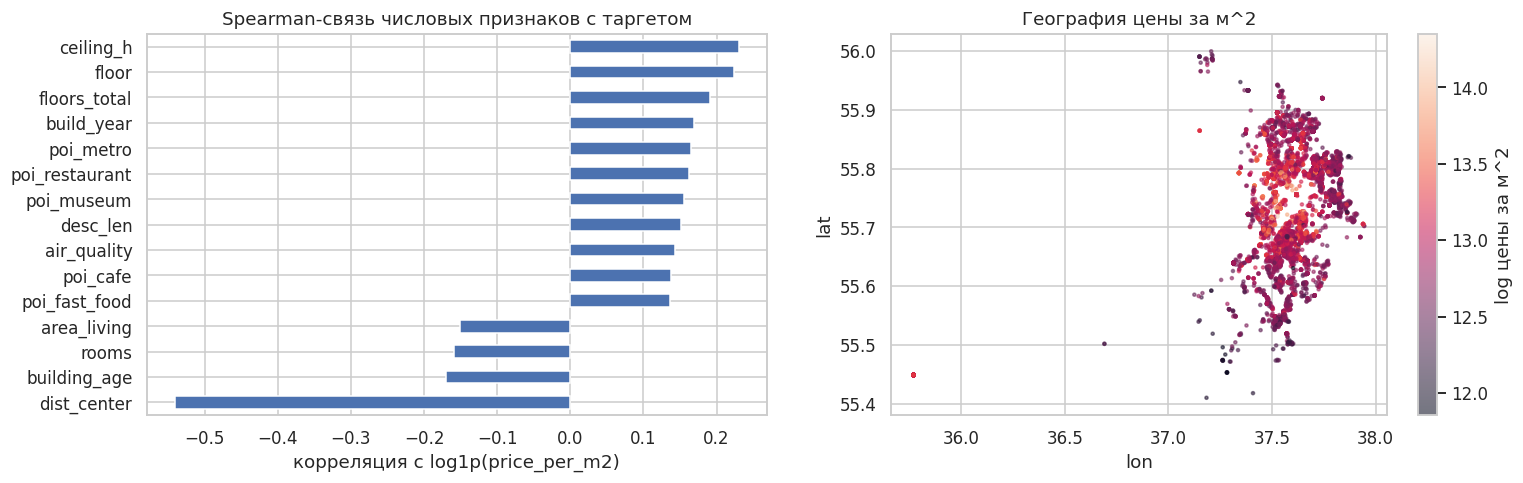

,spearman_corr
dist_center,-0.540
ceiling_h,0.230
floor,0.224
floors_total,0.191
building_age,-0.169
build_year,0.169
poi_metro,0.165
poi_restaurant,0.162
rooms,-0.159
poi_museum,0.155


In [32]:
#добавила Cпирмен-корреляции числовых признаков с таргетом и географическую карту цены за м^2
num_for_corr = [c for c in NUM_FEATURES if model_input[c].nunique(dropna=True) > 2]
corr = pd.Series({c: model_input[c].corr(eda['log_price_per_m2'], method='spearman')
                  for c in num_for_corr}).dropna()
corr = corr.reindex(corr.abs().sort_values(ascending=False).index).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
corr.sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Spearman-связь числовых признаков с таргетом')
axes[0].set_xlabel('корреляция с log1p(price_per_m2)')

geo = data.dropna(subset=['lat', 'lon']).copy()
sc = axes[1].scatter(geo['lon'], geo['lat'], c=np.log1p(geo['price_per_m2']), s=4, alpha=0.55)
plt.colorbar(sc, ax=axes[1], label='log цены за м^2')
axes[1].set_title('География цены за м^2')
axes[1].set_xlabel('lon')
axes[1].set_ylabel('lat')
plt.show()

display(corr.to_frame('spearman_corr').round(3))


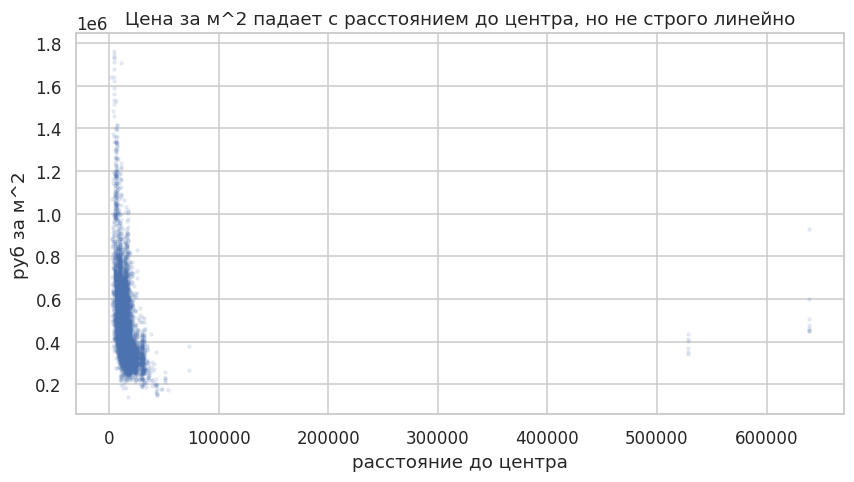

,dist_center,price_per_m2,n
dist_bin,,,
"(1696.499, 6125.3]",5440.0,734181.4,366
"(6125.3, 7736.6]",7261.4,558510.6,361
"(7736.6, 9052.6]",8490.9,527145.9,356
"(9052.6, 9952.5]",9415.0,584346.0,360
"(9952.5, 10742.0]",10370.1,515907.7,380


In [33]:
#добавила график нелинейной зависимости цены за м^2 от расстояния до центра
center = data.dropna(subset=['dist_center', 'price_per_m2']).copy()
center['dist_bin'] = pd.qcut(center['dist_center'], q=20, duplicates='drop')
trend = center.groupby('dist_bin', observed=True).agg(
    dist_center=('dist_center', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    n=('price_per_m2', 'size'))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(center['dist_center'], center['price_per_m2'], s=4, alpha=0.10)
ax.plot(trend['dist_center'], trend['price_per_m2'], lw=2)
ax.set_title('Цена за м^2 падает с расстоянием до центра, но не строго линейно')
ax.set_xlabel('расстояние до центра')
ax.set_ylabel('руб за м^2')
plt.show()

display(trend.head().round(1))


### 4.1. Углублённая первичная аналитика: взаимосвязи признаков

Здесь цель — не «нарисовать ещё графиков», а заранее понять, какие эффекты должна поймать модель. Поэтому дальше смотрим не только одиночные признаки, а связки: новостройка/вторичка х комнатность, округ х сегмент, расстояние до центра х тип объекта, этажность/возраст дома, станции метро и длину описания.

,n,share,median_price_mln,median_ppm_k,median_area,median_dist_center,median_metro_time,median_desc_len
segment,,,,,,,,
вторичка,2506,0.25,24.26,436.03,57.2,13356.7,11.0,1118.0
новостройка,7408,0.75,23.42,444.49,55.0,13738.8,11.0,1397.0


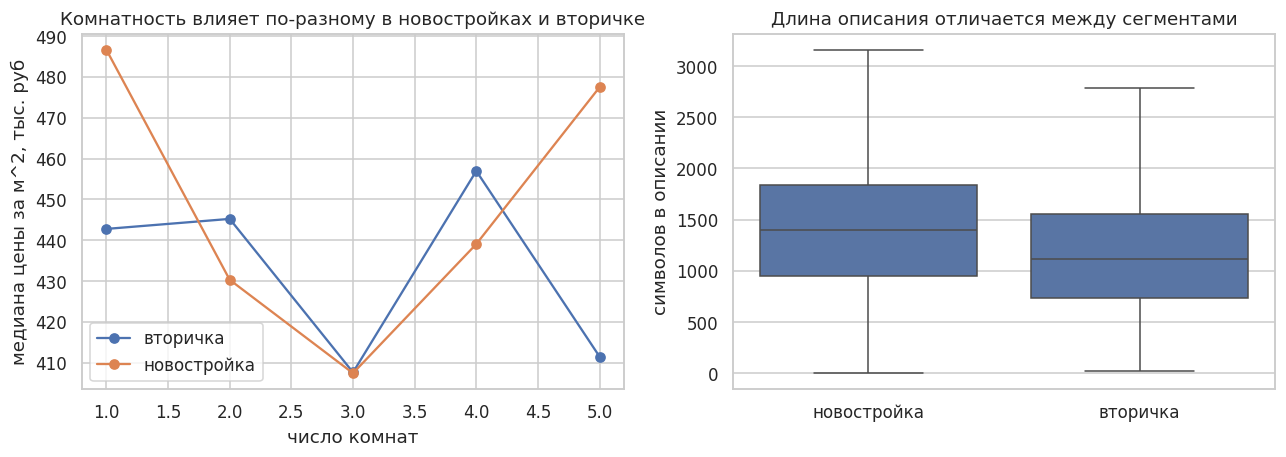

,segment,rooms,count,median
0,вторичка,1.0,527,442786.1
5,новостройка,1.0,2232,486650.0
1,вторичка,2.0,887,445238.1
6,новостройка,2.0,2817,430321.8
2,вторичка,3.0,689,407653.9
7,новостройка,3.0,1796,407448.5
3,вторичка,4.0,220,456978.3
8,новостройка,4.0,384,439075.9
4,вторичка,5.0,52,411500.8
9,новостройка,5.0,70,477500.0


In [34]:
# сравним новостройки и вторичку
seg = data.copy()
seg['segment'] = np.where(seg['is_newbuild'] == 1, 'новостройка', 'вторичка')
seg['log_price_per_m2'] = np.log1p(seg['price_per_m2'])

segment_profile = (seg.groupby('segment', observed=True)
    .agg(n=('price_per_m2', 'size'),
        median_price_mln=('price', lambda x: np.median(x) / 1e6),
        median_ppm_k=('price_per_m2', lambda x: np.median(x) / 1000),
        median_area=('area_total', 'median'),
        median_dist_center=('dist_center', 'median'),
        median_metro_time=('metro_time', 'median'),
        median_desc_len=('desc_len', 'median')))
segment_profile['share'] = segment_profile['n'] / len(seg)
display(segment_profile[['n','share','median_price_mln','median_ppm_k','median_area','median_dist_center','median_metro_time','median_desc_len']].round(2))

room_segment = (seg.groupby(['segment', 'rooms'], observed=True)['price_per_m2']
    .agg(count='size', median='median')
    .query('count >= 30')
    .reset_index())
room_pivot = room_segment.pivot(index='rooms', columns='segment', values='median') / 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
room_pivot.plot(marker='o', ax=axes[0])
axes[0].set_title('Комнатность влияет по-разному в новостройках и вторичке')
axes[0].set_xlabel('число комнат')
axes[0].set_ylabel('медиана цены за м^2, тыс. руб')
axes[0].legend(title='')

sns.boxplot(data=seg, x='segment', y='desc_len', showfliers=False, ax=axes[1])
axes[1].set_title('Длина описания отличается между сегментами')
axes[1].set_xlabel('')
axes[1].set_ylabel('символов в описании')
plt.show()

display(room_segment.sort_values(['rooms', 'segment']).round(1))


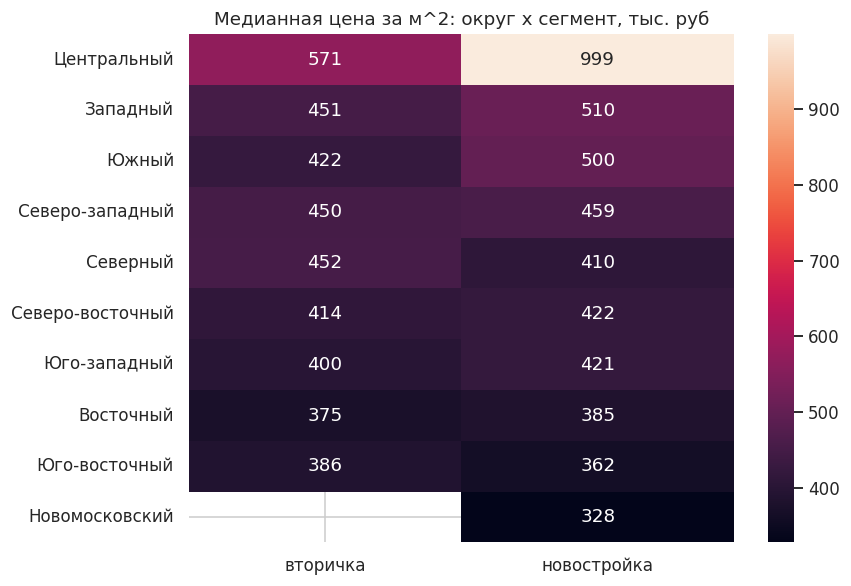

segment,вторичка,новостройка,gap_new_vs_old_%
okrug,,,
Центральный,571.1,998.9,74.9
Южный,422.2,500.0,18.4
Западный,450.8,510.1,13.2
Юго-западный,400.0,421.0,5.2
Восточный,375.0,385.1,2.7
Северо-восточный,413.7,421.8,1.9
Северо-западный,450.3,458.7,1.9
Юго-восточный,386.5,362.0,-6.3
Северный,452.5,410.2,-9.4


In [35]:
#добавила связку округ х сегмент. Один и тот же округ может вести себя по-разному для новостроек и вторички
okrug_segment = (seg.dropna(subset=['okrug'])
    .groupby(['okrug', 'segment'], observed=True)['price_per_m2']
    .agg(count='size', median='median').reset_index())

# Оставляем только достаточно представленные сочетания, чтобы не делать выводы по единичным объектам
okrug_segment = okrug_segment.query('count >= 30')
okrug_pivot = okrug_segment.pivot(index='okrug', columns='segment', values='median') / 1000
okrug_pivot = okrug_pivot.loc[okrug_pivot.median(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(okrug_pivot, annot=True, fmt='.0f', ax=ax)
ax.set_title('Медианная цена за м^2: округ х сегмент, тыс. руб')
ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

# Смотрим, где новостройки дороже/дешевле вторички внутри одного округа
okrug_gap = okrug_pivot.copy()
if {'новостройка', 'вторичка'}.issubset(okrug_gap.columns):
    okrug_gap['gap_new_vs_old_%'] = (okrug_gap['новостройка'] / okrug_gap['вторичка'] - 1) * 100
    display(okrug_gap.sort_values('gap_new_vs_old_%', ascending=False).round(1))
else:
    display(okrug_pivot.round(1))


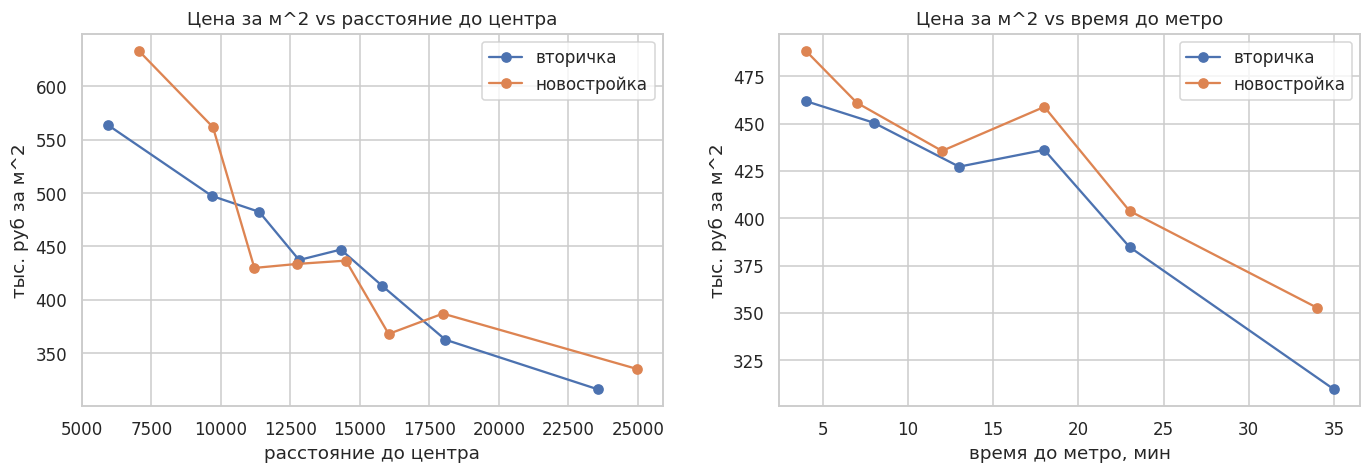

segment,вторичка,новостройка
dist_bin,,
"(1696.499, 8470.062]",563589.0,633413.0
"(8470.062, 10742.0]",497312.0,561728.0
"(10742.0, 12132.325]",482414.0,429891.0
"(12132.325, 13665.4]",437318.0,433655.0
"(13665.4, 14851.212]",447103.0,436737.0
"(14851.212, 16763.45]",413105.0,368073.0
"(16763.45, 20431.862]",362694.0,387123.0
"(20431.862, 638564.4]",316099.0,335392.0


segment,вторичка,новостройка
metro_bin,,
"(-0.001, 5.0]",461877.0,488500.0
"(5.0, 10.0]",450413.0,460976.0
"(10.0, 15.0]",427215.0,435543.0
"(15.0, 20.0]",436077.0,458804.0
"(20.0, 30.0]",384796.0,403851.0
"(30.0, 60.0]",309578.0,352734.0


In [36]:
# как расстояние до центра и метро влияют на цену
loc = seg.dropna(subset=['dist_center', 'price_per_m2']).copy()
loc['dist_bin'] = pd.qcut(loc['dist_center'], q=8, duplicates='drop')
dist_trend = loc.groupby(['dist_bin', 'segment'], observed=True).agg(
    dist_center=('dist_center', 'median'), price_per_m2=('price_per_m2', 'median'),
    n=('price_per_m2', 'size')).reset_index()

metro = seg.dropna(subset=['metro_time', 'price_per_m2']).copy()
metro['metro_bin'] = pd.cut(metro['metro_time'], bins=[0, 5, 10, 15, 20, 30, 60, 120], include_lowest=True)
metro_trend = metro.groupby(['metro_bin', 'segment'], observed=True).agg(
    metro_time=('metro_time', 'median'), price_per_m2=('price_per_m2', 'median'),
    n=('price_per_m2', 'size')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))

for name, part in dist_trend.groupby('segment', observed=True):
    axes[0].plot(part['dist_center'], part['price_per_m2'] / 1000, marker='o', label=name)
axes[0].set_title('Цена за м^2 vs расстояние до центра')
axes[0].set_xlabel('расстояние до центра')
axes[0].set_ylabel('тыс. руб за м^2')
axes[0].legend()

for name, part in metro_trend.groupby('segment', observed=True):
    axes[1].plot(part['metro_time'], part['price_per_m2'] / 1000, marker='o', label=name)
axes[1].set_title('Цена за м^2 vs время до метро')
axes[1].set_xlabel('время до метро, мин')
axes[1].set_ylabel('тыс. руб за м^2')
axes[1].legend()
plt.show()

display(dist_trend.pivot(index='dist_bin', columns='segment', values='price_per_m2').round(0))
display(metro_trend.pivot(index='metro_bin', columns='segment', values='price_per_m2').round(0))

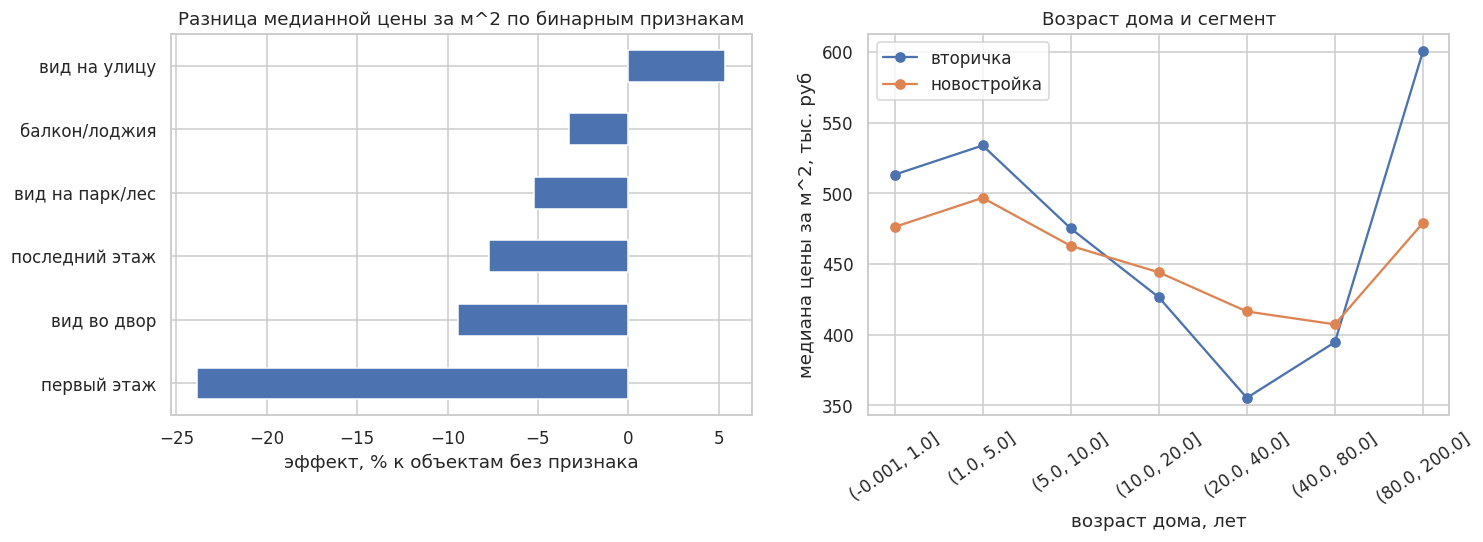

,feature,n_without,n_with,median_without_k,median_with_k,effect_%
0,первый этаж,9441,473,448.72,341.67,-23.86
3,вид во двор,2990,6924,474.48,429.86,-9.40
1,последний этаж,9439,475,444.70,410.53,-7.68
5,вид на парк/лес,9341,573,443.89,420.63,-5.24
2,балкон/лоджия,6692,3222,447.73,432.94,-3.30
4,вид на улицу,3559,6355,427.32,450.30,5.38


segment,вторичка,новостройка
age_bin,,
"(-0.001, 1.0]",513158.0,476190.0
"(1.0, 5.0]",533808.0,496797.0
"(5.0, 10.0]",475176.0,462849.0
"(10.0, 20.0]",426502.0,444145.0
"(20.0, 40.0]",355364.0,416433.0
"(40.0, 80.0]",394737.0,407353.0
"(80.0, 200.0]",600364.0,479075.0


In [37]:
#добавила анализ параметров дома и квартиры: этаж, возраст дома, класс, ремонт/отделка.
attr = seg.copy()
attr['age_bin'] = pd.cut(attr['building_age'], bins=[0, 1, 5, 10, 20, 40, 80, 200], include_lowest=True)
#include_lowest=True чтобы ноль попал в первый бин, а не выпал

flag_features = {
    'is_first_floor': 'первый этаж',
    'is_last_floor': 'последний этаж',
    'has_balcony_or_loggia': 'балкон/лоджия',
    'view_yard': 'вид во двор',
    'view_street': 'вид на улицу',
    'view_park': 'вид на парк/лес'}

flag_rows = []
for col, label in flag_features.items():
    tmp = attr[[col, 'price_per_m2']].copy()
    tmp[col] = tmp[col].fillna(0)
    base = tmp.groupby(col, observed=True)['price_per_m2'].agg(count='size', median='median')
    if 0 in base.index and 1 in base.index:
        flag_rows.append({'feature': label,
            'n_without': int(base.loc[0, 'count']),
            'n_with': int(base.loc[1, 'count']),
            'median_without_k': base.loc[0, 'median'] / 1000,
            'median_with_k': base.loc[1, 'median'] / 1000,
            'effect_%': (base.loc[1, 'median'] / base.loc[0, 'median'] - 1) * 100})
flag_effects = pd.DataFrame(flag_rows).sort_values('effect_%')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
flag_effects.plot(x='feature', y='effect_%', kind='barh', legend=False, ax=axes[0])
axes[0].set_title('Разница медианной цены за м^2 по бинарным признакам')
axes[0].set_xlabel('эффект, % к объектам без признака')
axes[0].set_ylabel('')

age_seg = (attr.groupby(['age_bin', 'segment'], observed=True)['price_per_m2']
           .agg(count='size', median='median').reset_index())
for name, part in age_seg.groupby('segment', observed=True):
    axes[1].plot(part['age_bin'].astype(str), part['median'] / 1000, marker='o', label=name)
axes[1].set_title('Возраст дома и сегмент')
axes[1].set_xlabel('возраст дома, лет')
axes[1].set_ylabel('медиана цены за м^2, тыс. руб')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='')
plt.show()

display(flag_effects.round(2))
display(age_seg.pivot(index='age_bin', columns='segment', values='median').round(0))



 Класс жилья


,count,median,uplift_%
housing_class,,,
бизнес,3169,484425.0,9.4
премиум,1376,481740.7,8.8
стандарт,629,431200.0,-2.6
комфорт,2234,403279.9,-8.9
бизнес,3169,484425.0,9.4
премиум,1376,481740.7,8.8
стандарт,629,431200.0,-2.6
комфорт,2234,403279.9,-8.9



 Ремонт


,count,median,uplift_%
repair,,,
дизайнерский,1726,500473.3,13.0
отсутствует,284,497310.2,12.3
под чистовой ремонт,68,457576.4,3.3
требует ремонта,973,451213.4,1.9
евро,1987,424107.1,-4.2
без ремонта,790,424025.0,-4.2
косметический,2346,397192.3,-10.3
дизайнерский,1726,500473.3,13.0
отсутствует,284,497310.2,12.3



 Отделка


,count,median,uplift_%
finishing,,,
без отделки,3994,455850.0,2.9
предчистовая,1122,447775.8,1.1
чистовая,1816,438098.0,-1.1
черновая,476,389290.1,-12.1
без отделки,3994,455850.0,2.9
предчистовая,1122,447775.8,1.1
чистовая,1816,438098.0,-1.1
черновая,476,389290.1,-12.1



 Материал стен


,count,median,uplift_%
wall_material,,,
Монолитно-кирпичный,1776,478852.7,8.1
Монолитный,3242,478723.4,8.1
Кирпичный,1831,448275.9,1.2
Блочный,514,403424.2,-8.9
Панельный,1027,394190.9,-11.0
Железобетон,1287,370844.0,-16.2
Монолитно-кирпичный,1776,478852.7,8.1
Монолитный,3242,478723.4,8.1
Кирпичный,1831,448275.9,1.2


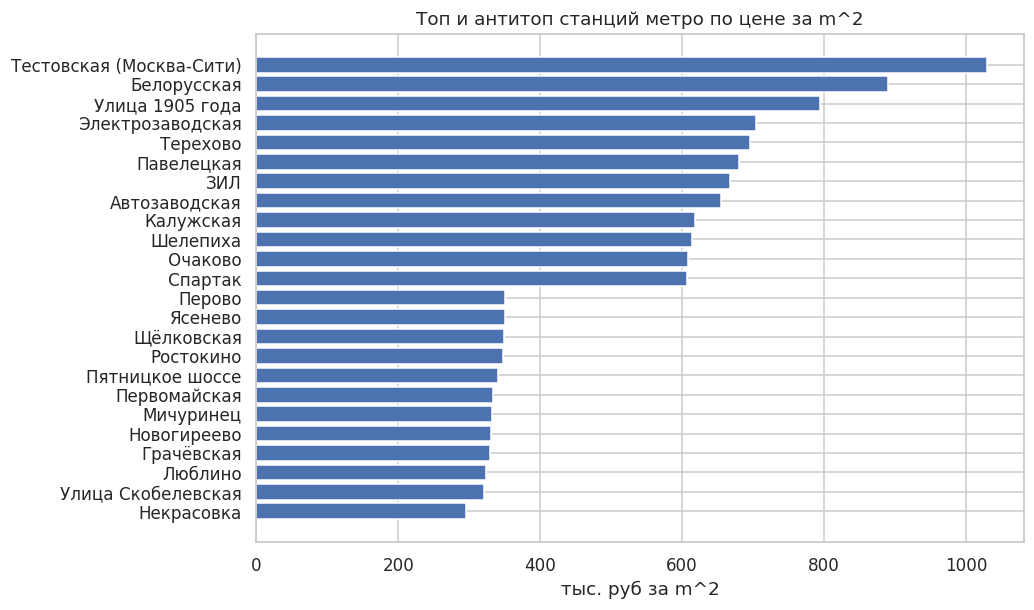

,count,median,uplift_%
metro_station,,,
Тестовская (Москва-Сити),48,1029500.0,132.5
Белорусская,56,890157.0,101.0
Улица 1905 года,41,793650.8,79.2
Электрозаводская,86,703542.3,58.9
Терехово,60,696158.4,57.2
Павелецкая,143,679734.8,53.5
ЗИЛ,40,667056.6,50.6
Автозаводская,66,654834.1,47.9
Калужская,286,618238.0,39.6


In [38]:
# категориальные признаки и цена
overall_ppm = seg['price_per_m2'].median()

def category_signal(df, col, min_count=50, top_n=10):
    stat = df.groupby(col, observed=True)['price_per_m2'].agg(
        count='size', median='median').dropna().query('count >= @min_count')
    stat['uplift_%'] = (stat['median'] / overall_ppm - 1) * 100
    return stat.sort_values('median', ascending=False).head(top_n), stat.sort_values('median', ascending=False).tail(top_n)

for col, title, min_count in [('housing_class', 'Класс жилья', 40),
                               ('repair', 'Ремонт', 50),
                               ('finishing', 'Отделка', 50),
                               ('wall_material', 'Материал стен', 50)]:
    top, bottom = category_signal(seg, col, min_count=min_count, top_n=8)
    print('\n', title)
    display(pd.concat([top, bottom]).round(1))

metro_top, metro_bottom = category_signal(seg, 'metro_station', min_count=40, top_n=12)
metro_signal = pd.concat([metro_top, metro_bottom])

fig, ax = plt.subplots(figsize=(9, 6))
metro_plot = metro_signal.sort_values('median')
ax.barh(metro_plot.index.astype(str), metro_plot['median'] / 1000)
ax.set_title('Топ и антитоп станций метро по цене за m^2')
ax.set_xlabel('тыс. руб за m^2')
plt.show()

metro_signal[['count', 'median', 'uplift_%']].round(1)

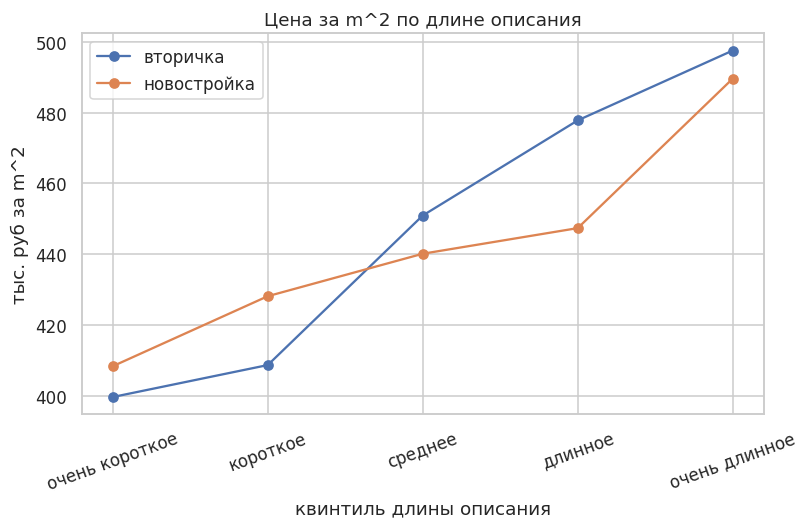

segment,вторичка,новостройка
desc_bin,,
очень короткое,399714.0,408409.0
короткое,408736.0,428171.0
среднее,450943.0,440155.0
длинное,477797.0,447390.0
очень длинное,497512.0,489588.0


segment,вторичка,новостройка
missing_bin,,
<2,NaN,412500.0
2,NaN,428274.0
3,401172.0,474190.0
4,422885.0,489840.0
>4,498638.0,477961.0


In [39]:
# описание и пропуски vs цена
quality = seg.copy()
quality['desc_bin'] = pd.qcut(quality['desc_len'].rank(method='first'), q=5,
    labels=['очень короткое','короткое','среднее','длинное','очень длинное'])
quality['missing_features_share'] = model_input.isna().mean(axis=1)

miss_order = ['<2', '2', '3', '4', '>4']
quality['missing_bin'] = pd.Categorical(
    pd.qcut(quality['missing_features_share'].rank(method='first'), q=5, labels=miss_order),
    categories=miss_order, ordered=True)

desc_stat = quality.groupby(['desc_bin', 'segment'], observed=True)['price_per_m2'].agg(
    count='size', median='median').reset_index()
miss_stat = quality.groupby(['missing_bin', 'segment'], observed=True)['price_per_m2'].agg(
    count='size', median='median').reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))

for name, part in desc_stat.groupby('segment', observed=True):
    ax.plot(part['desc_bin'].astype(str), part['median'] / 1000, marker='o', label=name)
ax.set_title('Цена за m^2 по длине описания')
ax.set_xlabel('квинтиль длины описания')
ax.set_ylabel('тыс. руб за m^2')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.show()

display(desc_stat.pivot(index='desc_bin', columns='segment', values='median').round(0))
display(miss_stat.pivot(index='missing_bin', columns='segment', values='median').round(0))

**Что стало видно после углубления первичной аналитики:**

1. Новостройки и вторичка похожи по медианной цене за м^2, но устроены по-разному: различаются структура комнатности, заполненность карточек, набор доступных признаков и реакция цены на локацию. Поэтому `is_newbuild` нельзя считать второстепенной колонкой - это фактически переключатель рыночного режима.
2. Локация работает не одной переменной. Расстояние до центра - самый сильный и нелинейный сигнал, но округ и станция метро добавляют локальные премии/дисконты, которые простой числовой признак не поймает. Это аргумент в пользу embeddings для `metro_station` и отдельного учёта округа.
3. Цена за м^2 зависит от связок признаков: комнатность х сегмент, округ х сегмент, возраст дома х сегмент. Значит, обычная линейная модель должна проигрывать, потому что ей сложно без ручных interaction-features восстановить такие эффекты.
4. Этаж, возраст дома, класс жилья, ремонт/отделка и материал стен дают понятные рыночные различия. Эти признаки важны не только технически, но и бизнесово: они объясняют, почему две квартиры одинаковой площади и удалённости от центра могут иметь разные цены.
5. Длина описания и доля пропусков связаны с ценовым сегментом. Это полезная связка с заданием 2: текстовая часть проекта может дополнять табличную модель за счёт анализа качества описания объявления.

Выводы EDA:

- Новостройки и вторичка по медиане цены за m^2 близки, но отличаются по структуре признаков и заполненности карточек. is_newbuild оставляю как отдельный признак.
- Расстояние до центра - самый сильный ценовой сигнал, зависимость нелинейная. - Округ и станция метро добавляют локальные премии. У metro_station высокая кардинальность, стоит попробовать embeddings.
- Есть признаки с высокой корреляцией: комнатность х сегмент, округ х сегмент, возраст х сегмент. Линейная модель без ручных фичей такое не поймает.
- Этаж, возраст дома, ремонт, класс жилья, материал стен - всё влияет на цену.
- Длина описания и доля пропусков коррелируют с ценовым сегментом, может быть полезно для задания 2.
- Таргет - log1p(price_per_m2), полная цена восстанавливается через площадь после прогноза.

## 5. Разбиение Train / Val / Test и постановка таргета

Разобьем выборку на train, val и test для более точной оценки моделей. По val выбираем лучшую модель и подбираем гиперпараметры, а по test уже фиксируем итоговый результат.
В качестве таргета берем log1p(price_per_m2), одинаковый для всех моделей. Еще отнормируем его по train: (y - mean) / std

Ps. были попытки обучить на y, (y - mean), но (y - mean) / std дал лучший резалт

In [40]:
y_log_ppm = np.log1p((data['price'] / data['area_total']).values)

SPLIT_KIND = 'random'
TARGET_KIND = 'price_per_m2'

def random_split(n, seed=SEED):
    tr, rest = train_test_split(np.arange(n), test_size=0.30, random_state=seed)
    va, te = train_test_split(rest, test_size=0.50, random_state=seed)
    return tr, va, te

y_log = y_log_ppm
idx_tr, idx_va, idx_te = random_split(len(data))

print('train:', len(idx_tr), 'val:', len(idx_va), 'test:', len(idx_te))

# обратное преобразование, лог цены за m^2 -> цена квартиры
def log_to_price(y_log, df_part):
    ppm = np.expm1(np.asarray(y_log))
    return ppm * df_part['area_total'].to_numpy()

def regression_metrics(y_true_log, y_pred_log, df_part):
    p = np.clip(log_to_price(y_pred_log, df_part), 1.0, None)
    t = log_to_price(y_true_log, df_part)
    ape = np.abs(p - t) / t
    return {'MAPE': float(ape.mean() * 100),
            'MdAPE': float(np.median(ape) * 100),
            'RMSLE': float(np.sqrt(np.mean((np.log1p(p) - np.log1p(t)) ** 2)))}

# стандартизация таргета
def fit_target_stats(y, idx):
    return {'mean': y[idx].mean(), 'std': y[idx].std()}

def encode_target(y, stats):
    return (y - stats['mean']) / stats['std']

def decode_target(z, stats):
    return np.asarray(z) * stats['std'] + stats['mean']

train: 6939 val: 1487 test: 1488


В качестве метрик качества мы взяли

- MAPE (Mean Absolute Percentage Error) показывает среднюю ошибку в процентах. Например MAPE=15 значит модель в среднем ошибается на 15% от реальной цены. Это удобно потому что ошибка не зависит от масштаба, квартира за 5 млн и за 50 млн оцениваются одинаково справедливо. Минус в том что MAPE чувствителен к выбросам, одна квартира с ошибкой в 200% может сильно испортить среднее.

- MdAPE (Median Absolute Percentage Error) решает эту проблему. Медиана не реагирует на единичные выбросы, поэтому показывает как модель работает на типичной квартире. Если MAPE сильно больше MdAPE, значит есть объекты на которых модель промахивается очень сильно.

- RMSLE (Root Mean Squared Log Error) считает дисперсию ошибки на логарифмической функции. За счет этого ошибка на дешевых и дорогих квартирах вносит сопоставимый вклад. Еще RMSLE сильнее штрафует за занижение цены чем за завышение, что для оценки недвижимости имеет смысл.

## 6. Не-нейросетевые модели

На ИАД мы уже работали с табличными данными и использовали классические алгоритмы.

Проверим, смогут ли нейросети дать результат лучше. Обучим Ridge и XGBoost на тех же данных, потом будем сравнивать с нейросетями.

- Ridge — линейная модель, нижняя граница качества
- XGBoost — градиентный бустинг, хорошо работает с табличными данными


In [41]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterSampler

X_tab = data[NUM_FEATURES + CATS].copy()
for c in CATS:
    X_tab[c] = X_tab[c].fillna('missing').astype(str)
    print(c)

for c in CAT_HIGH:
    vc = X_tab[c].iloc[idx_tr].value_counts()
    keep = set(vc[vc >= 5].index)
    X_tab[c] = X_tab[c].where(X_tab[c].isin(keep), 'rare')
    print(c)

repair
finishing
housing_class
deal_type
housing_type
wall_material
ceiling_type
okrug
ownership_years
accreditation
metro_station
house_series
metro_station
house_series


In [38]:
imp = SimpleImputer(strategy='median')
scaler = StandardScaler()
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_num_tr = scaler.fit_transform(imp.fit_transform(X_tab[NUM_FEATURES].iloc[idx_tr]))
X_num_va = scaler.transform(imp.transform(X_tab[NUM_FEATURES].iloc[idx_va]))
X_num_te = scaler.transform(imp.transform(X_tab[NUM_FEATURES].iloc[idx_te]))

X_cat_tr = enc.fit_transform(X_tab[CATS].iloc[idx_tr])
X_cat_va = enc.transform(X_tab[CATS].iloc[idx_va])
X_cat_te = enc.transform(X_tab[CATS].iloc[idx_te])

X_tr = np.hstack([X_num_tr, X_cat_tr])
X_va = np.hstack([X_num_va, X_cat_va])
X_te = np.hstack([X_num_te, X_cat_te])

results_ridge = []
for alpha in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]:
    r = Ridge(alpha=alpha)
    r.fit(X_tr, y_log[idx_tr])
    m = regression_metrics(y_log[idx_va], r.predict(X_va), data.iloc[idx_va])
    results_ridge.append({'alpha': alpha, 'MAPE': m['MAPE']})
    print(f"alpha={alpha}: MAPE={m['MAPE']:.2f}%")

best_alpha = pd.DataFrame(results_ridge).sort_values('MAPE').iloc[0]['alpha']
ridge_best = Ridge(alpha=best_alpha).fit(X_tr, y_log[idx_tr])
m_ridge = regression_metrics(y_log[idx_te], ridge_best.predict(X_te), data.iloc[idx_te])
print()
print(f'Ridge test (alpha={best_alpha}):', {k: round(v, 2) for k, v in m_ridge.items()})

alpha=0.01: MAPE=22.45%
alpha=0.1: MAPE=22.45%
alpha=0.5: MAPE=22.45%
alpha=1.0: MAPE=22.45%
alpha=5.0: MAPE=22.45%
alpha=10.0: MAPE=22.45%
alpha=50.0: MAPE=22.46%
alpha=100.0: MAPE=22.46%

Ridge test (alpha=0.01): {'MAPE': 21.89, 'MdAPE': 17.79, 'RMSLE': 0.28}


In [39]:
from xgboost import XGBRegressor

param_grid = {
    'n_estimators':     [500, 1000, 2000, 3000],
    'max_depth':        [4, 7, 10],
    'learning_rate':    [0.01, 0.05, 0.1],
    'reg_lambda':       [0.1, 1.0, 10.0],
    'reg_alpha':        [0, 0.1, 1.0],
    'min_child_weight': [5, 10, 20, 50]
}

sampler = list(ParameterSampler(param_grid, n_iter=20, random_state=SEED))
results_xgb = []

for i, params in enumerate(sampler):
    model = XGBRegressor(**params, objective='reg:absoluteerror',
                         early_stopping_rounds=50, verbosity=0, random_state=SEED)
    model.fit(X_tr, y_log[idx_tr], eval_set=[(X_va, y_log[idx_va])], verbose=False)
    pred_va = model.predict(X_va)
    m = regression_metrics(y_log[idx_va], pred_va, data.iloc[idx_va])
    results_xgb.append({**params, 'MAPE': m['MAPE']})
    print(f"[{i+1}/20] MAPE={m['MAPE']:.2f}%", params)

results_xgb_df = pd.DataFrame(results_xgb).sort_values('MAPE')
best_params = results_xgb_df.iloc[0].drop('MAPE').to_dict()
for k in ['n_estimators', 'max_depth', 'min_child_weight']:
    if k in best_params:
        best_params[k] = int(best_params[k])

xgb_best = XGBRegressor(**best_params, objective='reg:absoluteerror',
                        early_stopping_rounds=50, verbosity=0, random_state=SEED)
xgb_best.fit(X_tr, y_log[idx_tr], eval_set=[(X_va, y_log[idx_va])], verbose=False)
m_xgb = regression_metrics(y_log[idx_te], xgb_best.predict(X_te), data.iloc[idx_te])

print()
print('Ridge:', {k: round(v, 2) for k, v in m_ridge.items()})
print('XGBoost:', {k: round(v, 2) for k, v in m_xgb.items()})

[1/20] MAPE=11.08% {'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 2000, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05}
[2/20] MAPE=10.84% {'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 2000, 'min_child_weight': 10, 'max_depth': 10, 'learning_rate': 0.01}
[3/20] MAPE=11.01% {'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 2000, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.05}
[4/20] MAPE=11.00% {'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 2000, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.1}
[5/20] MAPE=11.16% {'reg_lambda': 0.1, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.1}
[6/20] MAPE=11.69% {'reg_lambda': 10.0, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 50, 'max_depth': 4, 'learning_rate': 0.1}
[7/20] MAPE=12.10% {'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.05}
[8/20] MAPE=

Ridge дал MAPE 21.89%, XGBoost 10.92% - бустинг лучше почти в два раза. Значит в данных много нелинейных зависимостей, которые линейная модель не ловит. Посмотрим смогут ли нейросети приблизиться к XGBoost или обойти его.

## 7. Препроцессинг для нейронных сетей

Рассмотрим, есть ли особенности у нейросетей и как можно заранее повысить точность их предсказаний.

В отличие от деревьев, нейросети чувствительны к масштабу входных данных (https://habr.com/ru/articles/527860/). Если один признак в диапазоне 0–1, а другой в тысячах, градиенты будут нестабильными и сеть будет плохо обучаться. Поэтому числовые признаки заполняем медианой и масштабируем через StandardScaler. Для колонок с большой долей пропусков добавляем бинарный флаг (1 = пропуск), потому что сам факт отсутствия значения может нести сигнал.

С категориальными признаками пробуем два варианта. Первый - one-hot, он простой и работает когда категорий не очень много. Второй - nn.Embedding, когда каждая категория превращается в обучаемый вектор.

Препроцессор сохраняем в MLflow вместе с моделью, чтобы на новых данных воспроизвести те же преобразования.

In [42]:
class Preprocessor:
    def __init__(self, num_cols, cat_cols, cat_mode='onehot', miss_thr=0.05):
        self.num_cols = list(num_cols)
        self.cat_cols = list(cat_cols)
        self.cat_mode = cat_mode  # onehot или embed
        self.miss_thr = miss_thr  # порог доли пропусков для флага

    def fit(self, df):
        nf = df[self.num_cols]
        self.miss_cols = [c for c in self.num_cols if nf[c].isna().mean() > self.miss_thr] # колонки где пропусков больше порога, для них потом сделаем бинарные флаги
        self.median = nf.median()
        self.scaler = StandardScaler().fit(nf.fillna(self.median).values)


        if self.cat_mode == 'onehot':
            self.ohe = OneHotEncoder(handle_unknown='ignore', min_frequency=20, # редкие категории (< 20 раз) sklearn игнорим
                                     sparse_output=False, dtype=np.float32)
            self.ohe.fit(df[self.cat_cols].fillna('missing').astype(str))
        else:
            # для embedding строим словарь категория -> номер
            # 0 зарезервирован под unknown, поэтому нумерация с 1 начинаем
            self.cat_maps = {}
            self.cat_sizes = []
            for c in self.cat_cols:
                vc = df[c].fillna('missing').astype(str).value_counts()
                vc = vc[vc >= 3].index  # встретилось меньше 3 раз = unknown
                self.cat_maps[c] = {v: i + 1 for i, v in enumerate(vc)}
                self.cat_sizes.append(len(vc) + 1)
        return self

    def transform(self, df):
        nf = df[self.num_cols]

        # 1 если значение пропущено
        miss = nf[self.miss_cols].isna().astype(np.float32).values
        num = self.scaler.transform(nf.fillna(self.median).values).astype(np.float32)
        out = {'num': torch.from_numpy(np.hstack([num, miss]))} # склеиваем числовые + флаги пропусков

        if self.cat_mode == 'onehot':
            # one-hot приклеиваем к числовым, категорий отдельно нет
            oh = self.ohe.transform(df[self.cat_cols].fillna('missing').astype(str))
            out['num'] = torch.cat([out['num'], torch.from_numpy(oh.astype(np.float32))], dim=1)
            out['cat'] = torch.zeros(len(df), 0, dtype=torch.long)
        else:
            # каждую категорию заменяем на номер из словаря, неизвестные = 0
            codes = np.stack([df[c].fillna('missing').astype(str).
                              map(self.cat_maps[c]).fillna(0).astype(np.int64).values for c in self.cat_cols], axis=1)
            out['cat'] = torch.from_numpy(codes)
        return out

    @property
    def n_num(self):
        n = len(self.num_cols) + len(self.miss_cols)
        if self.cat_mode == 'onehot':
            n += len(self.ohe.get_feature_names_out())
        return n

def make_tensors(prep):
    return (prep.transform(data.iloc[idx_tr]),
            prep.transform(data.iloc[idx_va]),
            prep.transform(data.iloc[idx_te]))

Если коротко, то пропуски заполняем медианами, нормализуем числа через StandardScaler и кодируем категории. One-hot используем когда уникальных значений немного (ремонт, округ), embedding когда их много (станция метро, серия дома). Все статистики считаются по train, чтобы val и test не влияли на обучение.

## 8. Архитектуры нейросетей

Сравниваем три архитектуры, внутри каждой подбираем гиперпараметры, при этом все сравниваемые модели остаются полносвязными сетями для табличной регрессии.

1. Простой MLP — базовая полносвязная сеть. Варьируем глубину, ширину слоев, функции активации, learning rate и размер батча.

2. MLP с регуляризацией — добавляем BatchNorm, Dropout. Экспериментируем с глубиной, шириной и силой dropout.

3. ResNet-like MLP + Embedding — residual-блоки с skip-connections для полносвязных слоев, категории кодируем через nn.Embedding вместо one-hot. Идея residual-блоков взята из статьи про модификации табличных нейросетей (https://habr.com/ru/articles/653171/). Подбираем количество блоков, размер embedding и dropout.

Все результаты сравниваем по MAPE на val, лучшую конфигурацию каждой архитектуры проверяем на test.

Логика сравнения такая: сначала берём простую сеть как нижнюю планку, затем добавляем регуляризованную глубину, потом меняем только способ кодирования категорий, и только после этого переходим к residual/PLR-архитектуре. Поэтому выводы можно объяснять по шагам, а не списком несвязанных экспериментов.


In [16]:
ACT = {'relu': nn.ReLU, 'leaky_relu': nn.LeakyReLU, 'gelu': nn.GELU}

In [43]:
class CatEmbeddings(nn.Module):
    # категории -> обучаемые эмбеддинги вместо one-hot
    # размер вектора = min(emb_max, половина числа категорий)
    def __init__(self, cardinalities, emb_max=24):
        super().__init__()
        self.embs = nn.ModuleList(
            [nn.Embedding(card, min(emb_max, (card + 1) // 2)) for card in cardinalities])
        self.out_dim = sum(e.embedding_dim for e in self.embs)

    def forward(self, x_cat): # x_cat: (B, n_cat)
        return torch.cat([emb(x_cat[:, i]) for i, emb in enumerate(self.embs)], dim=1) #https://docs.pytorch.org/docs/2.12/generated/torch.cat.html
        #клеим по столбцам (по признакам), а не по строкам


class NumEmbeddings(nn.Module):
    # PLR-эмбеддинги, где каждое число -> sin/cos с обучаемыми частотами -> linear -> relu
    def __init__(self, n_num, n_freq=24, sigma=0.05, d_emb=8):
        super().__init__()
        self.freqs = nn.Parameter(torch.randn(n_num, n_freq) * sigma)
        self.linear = nn.Linear(2 * n_freq, d_emb)
        self.out_dim = n_num * d_emb

    def forward(self, x_num):
        z = 2 * math.pi * x_num[:, :, None] * self.freqs
        z = torch.cat([torch.sin(z), torch.cos(z)], dim=-1)
        z = torch.relu(self.linear(z))
        return z.reshape(z.shape[0], -1)

In [44]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    # Строим самую простую простую MLP-модель
    # В ней только линейные слои и активации, без Dropout и нормализации.
    # Нужна как базовый вариант для сравнения и понимания примерно зоны переобучения
    def __init__(self, n_in, hidden=(128, 128), activation='relu'):
        super().__init__()
        act = ACT[activation]
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d, h), act()]
            d = h
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(d, 1)

    def forward(self, x_num, x_cat=None):
        x = self.body(x_num)
        x = self.head(x)
        return x.squeeze(1) #https://docs.pytorch.org/docs/2.12/generated/torch.squeeze.html убрать лишнюю размерность 1

In [45]:
class RegMLP(nn.Module):
    # Более сильная MLP-модель с регуляризацией
    # После линейных слоёв добавлены нормализация и Dropout
    # Категории можно подавать как one-hot или через embeddings
    def __init__(self, n_in, cardinalities=(), hidden=(512, 256, 128, 64),
                 activation='gelu', dropout=0.2, norm='batch', emb_max=24):
        super().__init__()

        self.cat_emb = CatEmbeddings(cardinalities, emb_max) if len(cardinalities) else None

        d = n_in
        if self.cat_emb is not None:
            d += self.cat_emb.out_dim

        act = ACT[activation]

        layers = []
        for h in hidden:
            layers.append(nn.Linear(d, h))

            if norm == 'batch':
                layers.append(nn.BatchNorm1d(h))
            elif norm == 'layer':
                layers.append(nn.LayerNorm(h))

            layers.append(act())
            layers.append(nn.Dropout(dropout))

            d = h

        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(d, 1)

    def forward(self, x_num, x_cat=None):
        if self.cat_emb is not None:
            x_cat = self.cat_emb(x_cat)
            x_num = torch.cat([x_num, x_cat], dim=1)

        x = self.body(x_num)
        x = self.head(x)
        return x.squeeze(1)

In [46]:
class ResidualBlock(nn.Module):
    # residual-блок: x + f(x), где f = norm -> linear -> act -> dropout -> linear
    def __init__(self, dim, hidden, dropout=0.1, activation='gelu'):
        super().__init__()
        self.norm = nn.BatchNorm1d(dim)
        self.lin1 = nn.Linear(dim, hidden)
        self.act = ACT[activation]()
        self.drop = nn.Dropout(dropout)
        self.lin2 = nn.Linear(hidden, dim)

    def forward(self, x):
        z = self.drop(self.act(self.lin1(self.norm(x))))
        return x + self.lin2(z)                      # skip-connection


class ResNetMLP(nn.Module):
    # resnet-подобный mlp; числовые -> PLR-эмбеддинги, категории -> обычные эмбеддинги
    # вход -> проекция в d_hidden -> residual-блоки -> голова
    # https://habr.com/ru/articles/653171/
    def __init__(self, n_num, cardinalities, n_blocks=3, d_hidden=256,
                 dropout=0.15, activation='gelu', emb_max=24, num_emb=8, num_freq=24):
        super().__init__()
        self.num_emb = NumEmbeddings(n_num, n_freq=num_freq, d_emb=num_emb)
        self.cat_emb = CatEmbeddings(cardinalities, emb_max)
        input_dim = self.num_emb.out_dim + self.cat_emb.out_dim
        self.proj = nn.Linear(input_dim, d_hidden)
        blocks = []
        for _ in range(n_blocks):
            block = ResidualBlock(d_hidden, 2 * d_hidden, dropout, activation)
            blocks.append(block)
        self.blocks = nn.Sequential(*blocks)
        self.norm = nn.BatchNorm1d(d_hidden)
        self.head = nn.Linear(d_hidden, 1)

    def forward(self, x_num, x_cat):
        x_num = self.num_emb(x_num)
        x_cat = self.cat_emb(x_cat)
        x = torch.cat([x_num, x_cat], dim=1)
        x = self.proj(x)
        x = self.blocks(x)
        x = self.norm(x)
        x = self.head(x)
        return x.squeeze(1)

## 9. Обучающий цикл

В этом разделе описан общий цикл обучения модели. Есть общий конфиг `CFG`, функция обучения на одной эпохе `train_one_epoch`, функция предсказания `predict` и функция `fit_model`, которая запускает обучение одной модели и считает метрики.

Используется регрессионная функция потерь RMLSE. Ранняя остановка делается по `val MAPE`, она показывает среднюю ошибку прогноза в процентах.

Модель обучается не на самой цене, а на стандартизованном значении `log1p(price_per_m2)`. Это делает обучение стабильнее. После предсказания значение переводится обратно в полную цену квартиры, и уже по ней считаются итоговые метрики.

В качестве основной функции потерь используется `nn.MSELoss` - стандартная функция потерь для задачи регрессии

Логирование в MLflow включается через флаг `CFG.use_mlflow`. Если он включён, для каждого запуска сохраняются параметры модели, метрики по эпохам, веса, препроцессор, конфиг обучения и статистики таргета. Это нужно, чтобы потом можно было восстановить обученную модель без повторного обучения.